# Enterprise Online Retail CLV Modeling

## 1. Executive Summary

The validated dataset supports **4,338 customers** and **18,532 invoice-level purchase events**. The model estimates **£10,369,750** of 12-month revenue, **£3,110,925** of gross margin under the explicit 30% course assumption, and **£2,955,975** of discounted CLV.

The top 20% contributes **67.7%**, so this is not an 80/20 dataset. At `p_alive < 0.70`, **3 high-LTV customers** enter priority retention. A hypothetical 10% order uplift creates **£2,060** discounted incremental margin and supports at most **£687 per targeted customer**. This is scenario analysis, not causal evidence.

LightGBM improves MAE versus a historic-rate baseline but worsens RMSE. BG/NBD + Gamma-Gamma is slightly stronger on the final holdout and produces **5.23×** top-decile lift. The five highest predicted-CLV CustomerIDs are **16446, 14646, 18102, 17450, 14096**.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display
from run_analysis import run_full_analysis

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Recompute all outputs: this notebook is executable, not a stale template.
summary = run_full_analysis()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

def show_table(name, rows=None):
    frame = pd.read_csv(TABLE_DIR / name)
    display(frame if rows is None else frame.head(rows))
    return frame

def show_figures(*names):
    for name in names:
        alt = name.removesuffix(".png").replace("_", " ")
        display(Image(filename=str(FIGURE_DIR / name), width=900, alt=alt))

print(
    f"Pipeline complete: {summary['dataset']['raw_rows']:,} raw rows; "
    f"{summary['customers']['usable']:,} scored customers; "
    f"{summary['artifacts']['tables']} tables; {summary['artifacts']['figures']} figures."
)

Pipeline complete: 541,909 raw rows; 4,338 scored customers; 28 tables; 15 figures.


## 2. Business Problem and Course Framework


This is Customer Lifetime Value analysis—not association-rule mining. The decision chain is **Customer Acquisition → Customer Retention → Customer Expansion**. Revenue is observed; cost, margin, CAC, contractual churn, and campaign treatment are absent. Assumptions and model estimates are labelled separately from observed data.

The primary scenario uses 30% gross margin and 10% annual discount. The effective monthly rate is `(1 + 0.10)^(1/12) - 1`. Holdout validation is chronological over 90 days.

In [2]:
show_table("analysis_assumptions.csv")

,Assumption,Value,Classification
0,Gross margin rate,0.3000,COURSE / SCENARIO ASSUMPTION; cost is absent
1,Annual discount rate,0.1000,COURSE / SCENARIO ASSUMPTION
2,Effective monthly discount rate,0.0080,Derived from annual assumption
3,BG/NBD penalizer course baseline,0.0100,COURSE BASELINE; numerically invalid for long-...
4,BG/NBD penalizer operational,0.0001,MODEL IMPLEMENTATION — smallest tested positiv...
5,Gamma-Gamma penalizer,0.0100,COURSE BASELINE
6,Holdout days,90.0000,TEMPORAL VALIDATION DESIGN
7,Probability Alive risk threshold,0.7000,MODEL-DERIVED PROXY; not observed churn
8,Observed CAC,NaN,UNAVAILABLE — never fabricated


,Assumption,Value,Classification
0,Gross margin rate,0.3000,COURSE / SCENARIO ASSUMPTION; cost is absent
1,Annual discount rate,0.1000,COURSE / SCENARIO ASSUMPTION
2,Effective monthly discount rate,0.0080,Derived from annual assumption
3,BG/NBD penalizer course baseline,0.0100,COURSE BASELINE; numerically invalid for long-...
4,BG/NBD penalizer operational,0.0001,MODEL IMPLEMENTATION — smallest tested positiv...
5,Gamma-Gamma penalizer,0.0100,COURSE BASELINE
6,Holdout days,90.0000,TEMPORAL VALIDATION DESIGN
7,Probability Alive risk threshold,0.7000,MODEL-DERIVED PROXY; not observed churn
8,Observed CAC,NaN,UNAVAILABLE — never fabricated


## 3. Dataset and Data Audit


The local CSV is the source of truth and remains unchanged outside Git. It contains **541,909 rows and 8 columns**. Extreme-value flags are diagnostics only; positive extreme purchases are not silently removed.

In [3]:
show_table("dataset_metadata.csv"); show_table("dataset_audit.csv")

,Field,Value
0,source_file,Online_Retail.csv
1,source_path,/Applications/MasterDegreeDS/961731 Business D...
2,sha256,5c1b5517919301b1da060b3dc486614f487da43515a9b2...
3,rows,541909
4,columns,8
5,column_names,InvoiceNo | StockCode | Description | Quantity...
6,pandas_dtypes,InvoiceNo:object | StockCode:object | Descript...


,Metric,Value,Classification
0,raw_row_count,541909,OBSERVED DATA
1,column_count,8,OBSERVED DATA
2,date_min,2010-12-01T08:26:00,OBSERVED DATA
3,date_max,2011-12-09T12:50:00,OBSERVED DATA
4,unique_invoices,25900,OBSERVED DATA
5,unique_customers,4372,OBSERVED DATA
6,unique_products,4070,OBSERVED DATA
7,countries,38,OBSERVED DATA
8,missing_CustomerID,135080,OBSERVED DATA
9,missing_Description,1454,OBSERVED DATA


,Metric,Value,Classification
0,raw_row_count,541909,OBSERVED DATA
1,column_count,8,OBSERVED DATA
2,date_min,2010-12-01T08:26:00,OBSERVED DATA
3,date_max,2011-12-09T12:50:00,OBSERVED DATA
4,unique_invoices,25900,OBSERVED DATA
5,unique_customers,4372,OBSERVED DATA
6,unique_products,4070,OBSERVED DATA
7,countries,38,OBSERVED DATA
8,missing_CustomerID,135080,OBSERVED DATA
9,missing_Description,1454,OBSERVED DATA


## 4. Data Cleaning


Positive-purchase hygiene requires a valid customer, invoice and date, `Quantity > 0`, `UnitPrice > 0`, no C/c cancellation prefix, and first occurrence of an exact duplicate. Rules overlap; their counts must not be added. The union excludes **149,217 rows**, leaving **392,692 line items**. SKU rows are aggregated to **18,532 `InvoiceNo × CustomerID` events**.

In [4]:
show_table("data_cleaning_audit.csv"); show_table("invoice_purchase_events.csv", 5)

,Rule,RowsAffected,PercentOfRawRows,BusinessMeaning
0,Missing CustomerID,135080,24.9267,Cannot link the purchase event to a customer.
1,Invalid CustomerID,0,0.0000,Customer identifier is non-positive or non-int...
2,Missing/blank InvoiceNo,0,0.0000,Cannot construct an invoice-level purchase event.
3,Cancellation invoice (C/c prefix),9288,1.7139,"Reversal/cancellation, not a positive purchase..."
4,Malformed/missing InvoiceDate,0,0.0000,Cannot place the event on the customer timeline.
5,Non-positive or non-numeric Quantity,10624,1.9605,"Return, reversal, or invalid unit quantity."
6,Non-positive or non-numeric UnitPrice,2517,0.4645,No valid positive economic value.
7,Exact duplicate line,5268,0.9721,Repeated source record; retain the first occur...
8,Any exclusion rule (deduplicated union),149217,27.5354,Rows excluded from positive-purchase CLV model...


,InvoiceNo,CustomerID,InvoiceDate,OrderRevenue,TotalUnits,UniqueProducts,InvoiceLines,Country
0,536365,17850,2010-12-01 08:26:00,139.1200,40,7,7,United Kingdom
1,536366,17850,2010-12-01 08:28:00,22.2000,12,2,2,United Kingdom
2,536367,13047,2010-12-01 08:34:00,278.7300,83,12,12,United Kingdom
3,536368,13047,2010-12-01 08:34:00,70.0500,15,4,4,United Kingdom
4,536369,13047,2010-12-01 08:35:00,17.8500,3,1,1,United Kingdom


,InvoiceNo,CustomerID,InvoiceDate,OrderRevenue,TotalUnits,UniqueProducts,InvoiceLines,Country
0,536365,17850,2010-12-01 08:26:00,139.1200,40,7,7,United Kingdom
1,536366,17850,2010-12-01 08:28:00,22.2000,12,2,2,United Kingdom
2,536367,13047,2010-12-01 08:34:00,278.7300,83,12,12,United Kingdom
3,536368,13047,2010-12-01 08:34:00,70.0500,15,4,4,United Kingdom
4,536369,13047,2010-12-01 08:35:00,17.8500,3,1,1,United Kingdom
...,...,...,...,...,...,...,...,...
18527,581583,13777,2011-12-09 12:23:00,124.6000,76,2,2,United Kingdom
18528,581584,13777,2011-12-09 12:25:00,140.6400,120,2,2,United Kingdom
18529,581585,15804,2011-12-09 12:31:00,329.0500,278,21,21,United Kingdom
18530,581586,13113,2011-12-09 12:49:00,339.2000,66,4,4,United Kingdom


## 5. Exploratory Data Analysis


The plots cover monthly revenue, active customers, recency, frequency, customer behavior, and empirical holdout repeat rate. Log transformations are labelled. The repeat-rate curve declines gradually; it does not support inventing a single defection cliff.

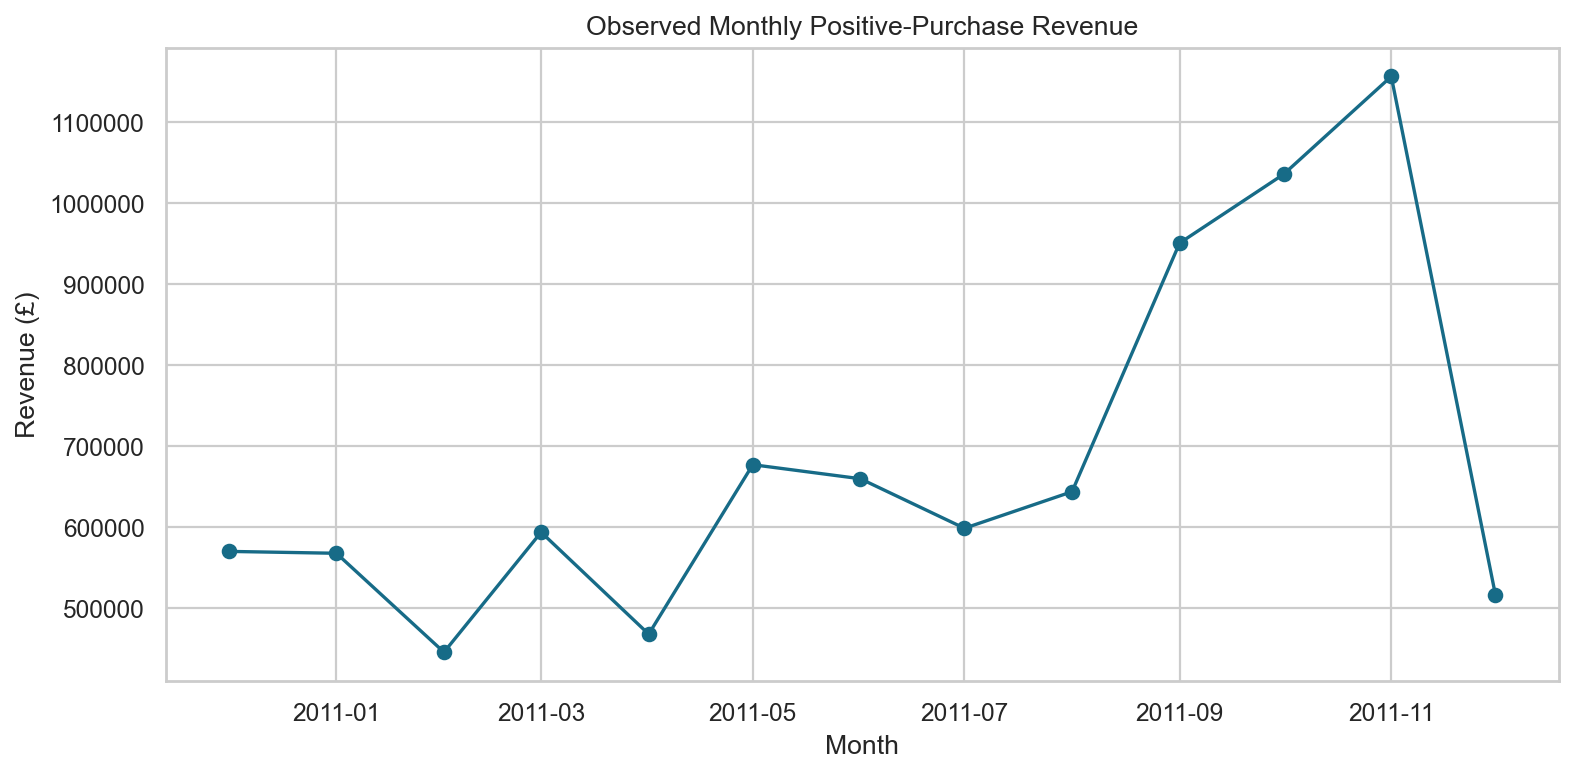

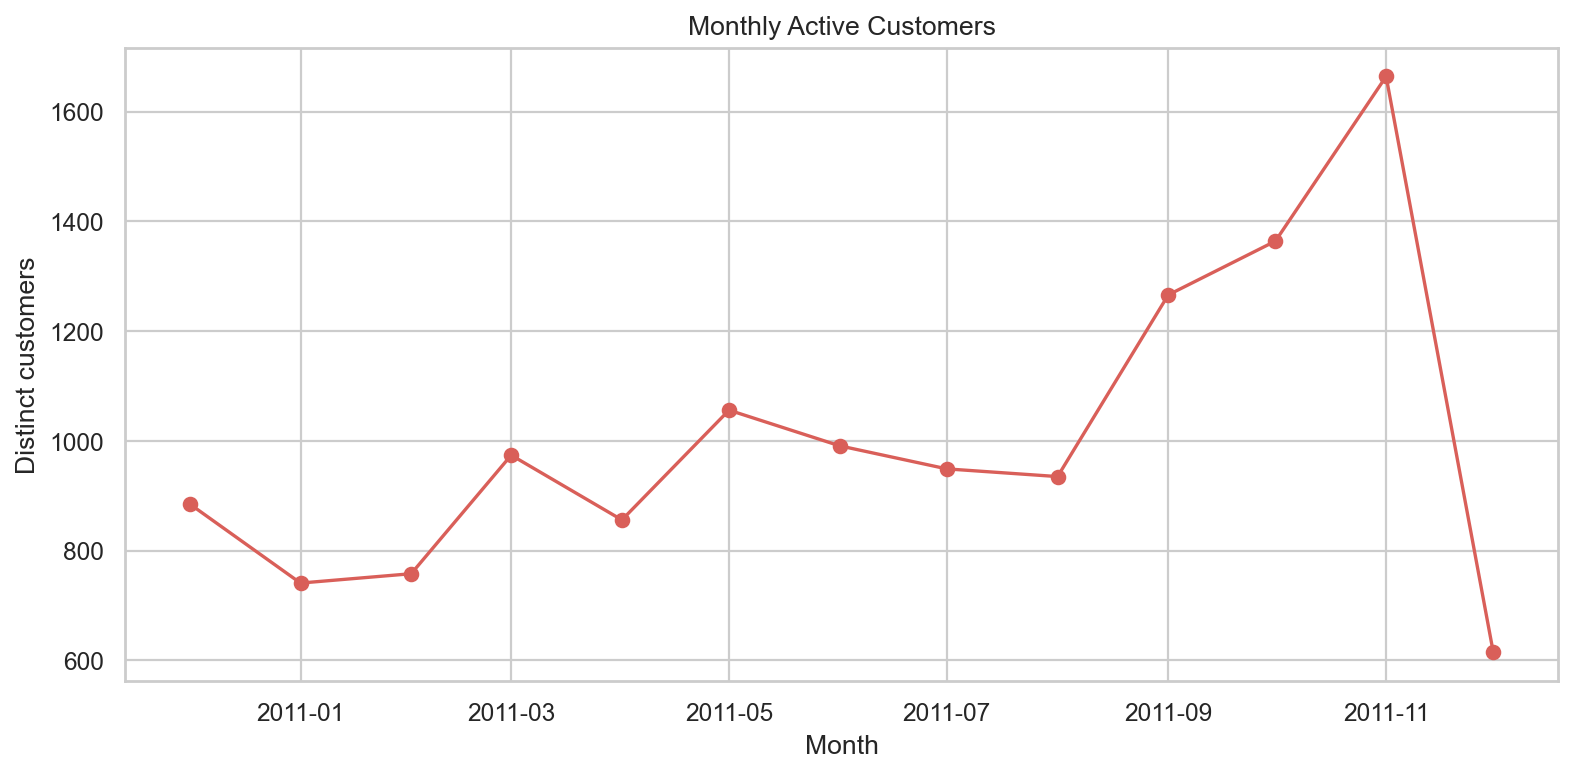

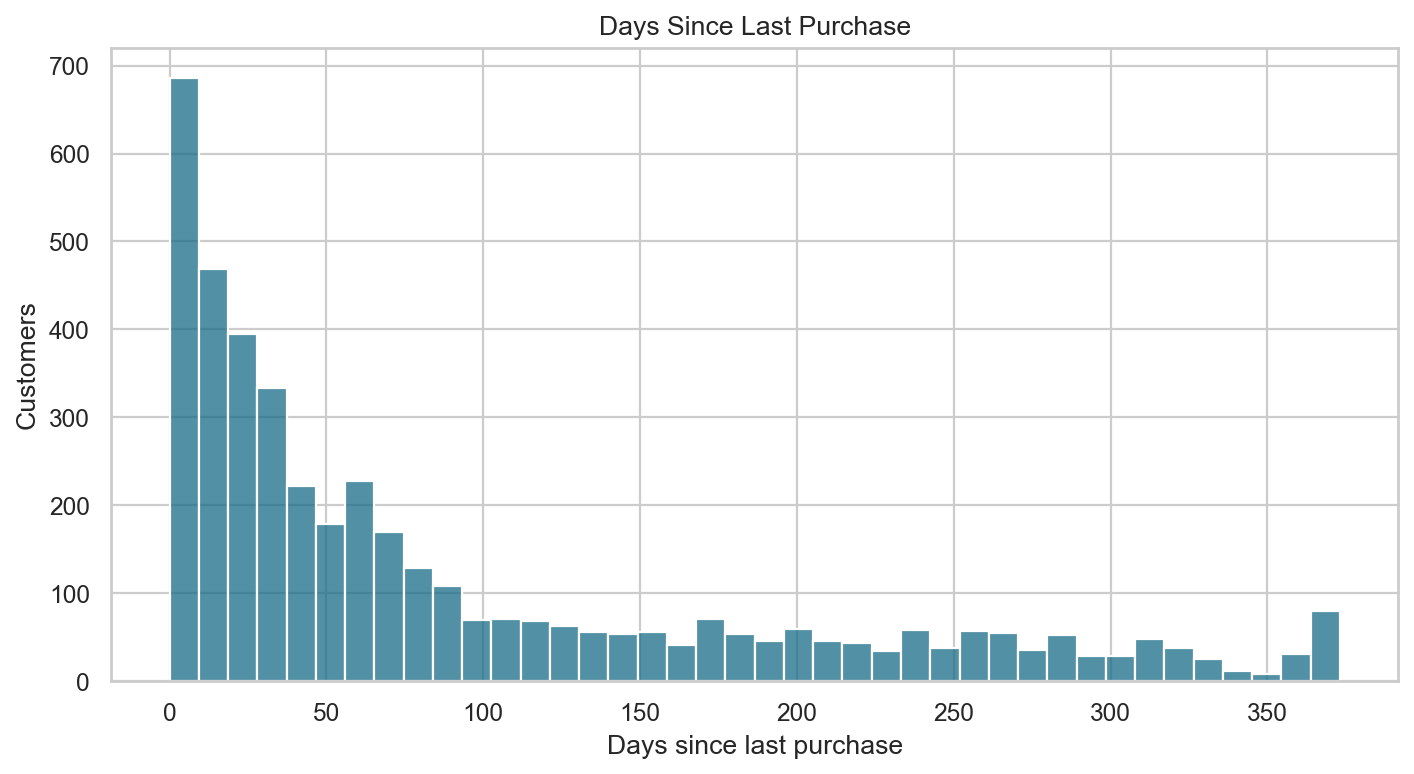

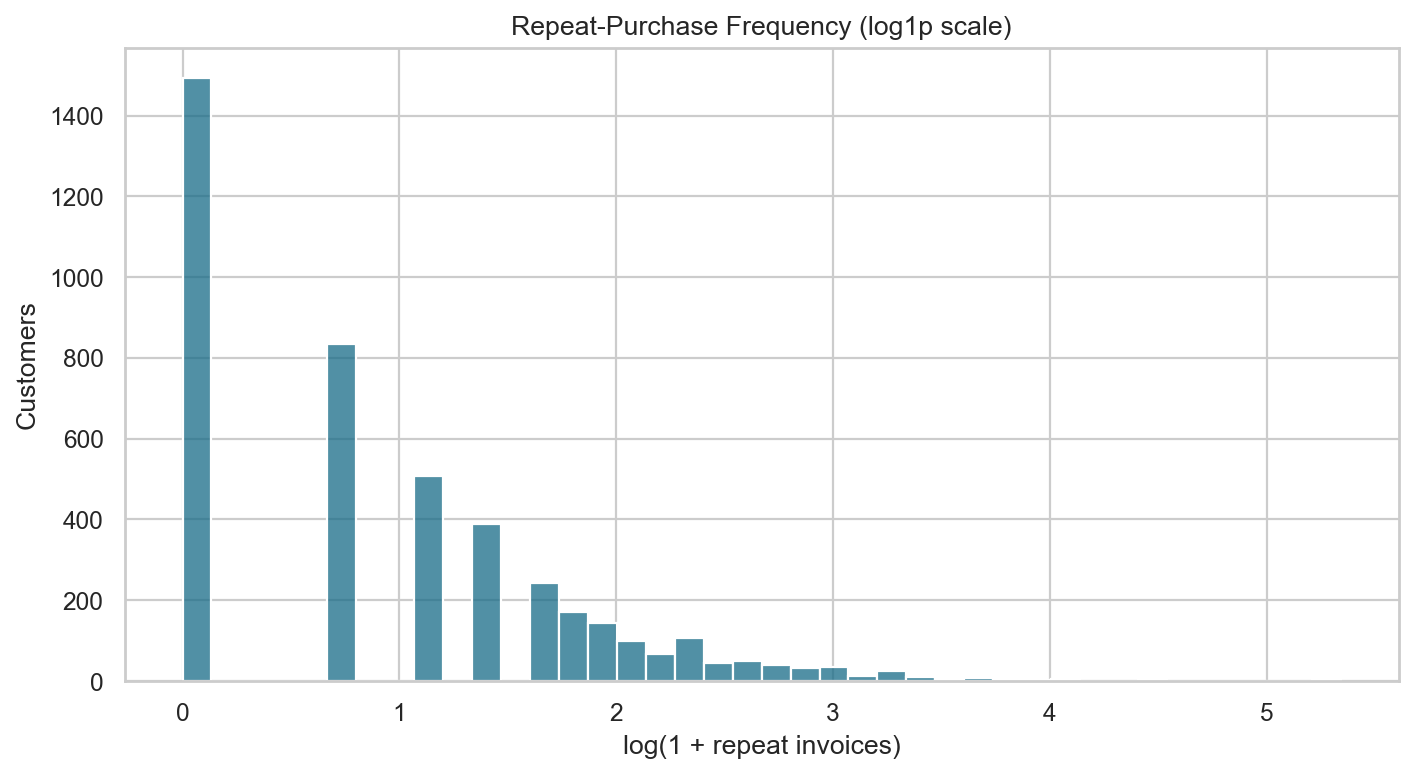

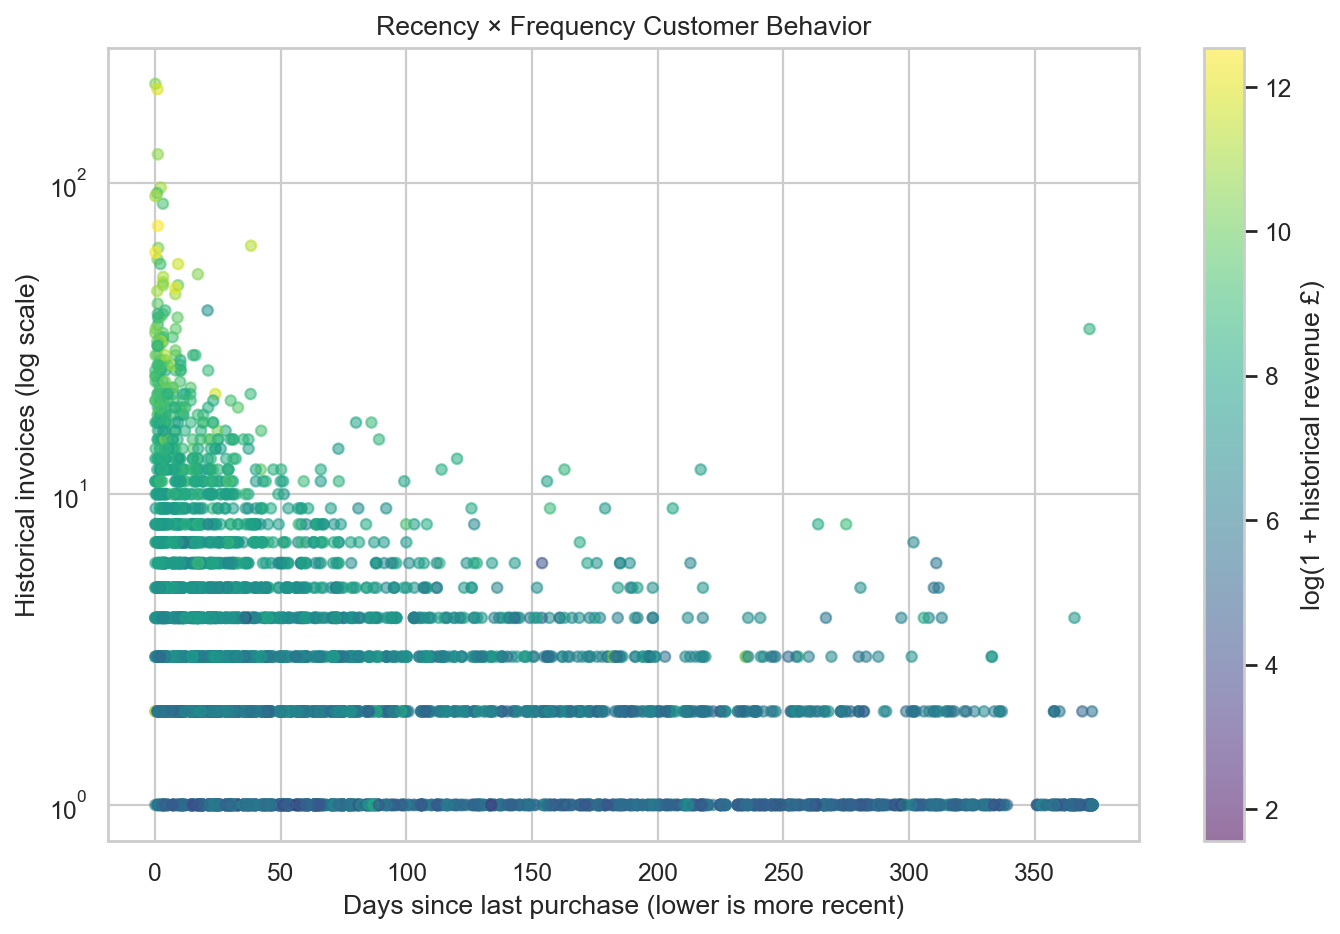

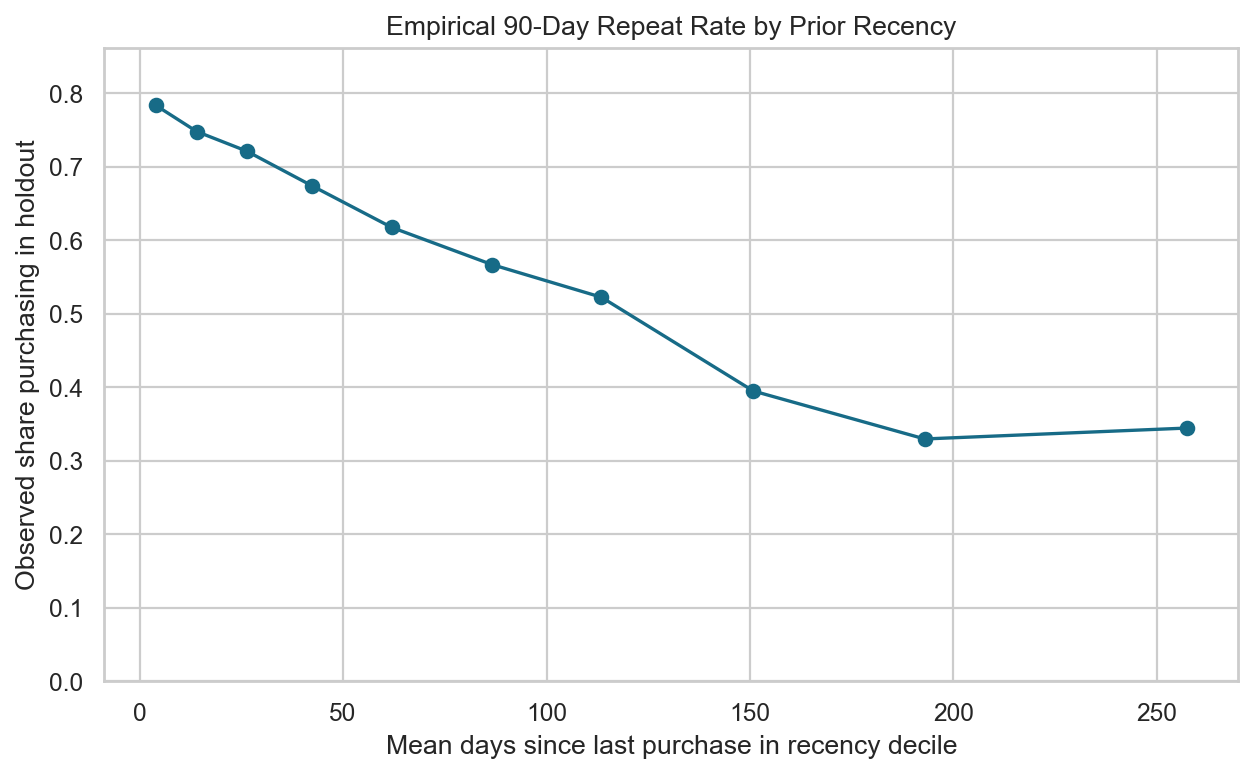

,RecencyBin,Customers,MeanDaysSinceLastPurchase,Observed90dRepeatRate
0,"(0.872, 8.128]",337,3.9724,0.7834
1,"(8.128, 19.087]",337,14.0197,0.7478
2,"(19.087, 33.994]",337,26.3211,0.7211
3,"(33.994, 51.071]",337,42.4670,0.6736
4,"(51.071, 74.042]",337,61.9767,0.6172
5,"(74.042, 97.818]",337,86.5502,0.5668
6,"(97.818, 127.83]",337,113.4784,0.5223
7,"(127.83, 170.971]",337,150.8171,0.3947
8,"(170.971, 220.945]",337,192.9530,0.3294
9,"(220.945, 283.123]",337,257.3490,0.3442


,RecencyBin,Customers,MeanDaysSinceLastPurchase,Observed90dRepeatRate
0,"(0.872, 8.128]",337,3.9724,0.7834
1,"(8.128, 19.087]",337,14.0197,0.7478
2,"(19.087, 33.994]",337,26.3211,0.7211
3,"(33.994, 51.071]",337,42.4670,0.6736
4,"(51.071, 74.042]",337,61.9767,0.6172
5,"(74.042, 97.818]",337,86.5502,0.5668
6,"(97.818, 127.83]",337,113.4784,0.5223
7,"(127.83, 170.971]",337,150.8171,0.3947
8,"(170.971, 220.945]",337,192.9530,0.3294
9,"(220.945, 283.123]",337,257.3490,0.3442


In [5]:
show_figures(
    "01_monthly_revenue.png", "02_monthly_active_customers.png",
    "03_recency_distribution.png", "04_frequency_distribution.png",
    "05_recency_frequency_behavior.png", "15_empirical_repeat_rate_by_recency.png"
)
show_table("empirical_repeat_rate_by_recency.csv")

## 6. Historic CLV and RFM Baselines


Historic annualized margin is `(Historical Revenue × 30% / max(Tenure Days, 1)) × 365`; 30% is assumed. Tie-safe percentile ranks produce 1–5 R, F and M scores. RFM ranks customers but is not a probabilistic future valuation.

In [6]:
rfmt = show_table("customer_rfmt.csv")
display(rfmt[["historic_clv_annual_margin", "R_score", "F_score", "M_score"]].describe())
display(rfmt[["CustomerID", "historic_clv_annual_margin", "RFM_score"]].head(10))

,CustomerID,first_purchase,last_purchase,historical_orders,historical_revenue,mean_order_value,median_order_value,std_order_value,max_order_value,total_units,active_purchase_days,country,monetary_value,frequency,bgnbd_recency,T,days_since_last_purchase,tenure_days,average_days_between_orders,historic_clv_annual_margin,R_score,F_score,M_score,RFM_score
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,"77,183.6000","77,183.6000","77,183.6000",0.0000,"77,183.6000",74215,1,United Kingdom,0.0000,0,0.0000,325.1174,325.1174,325.1174,NaN,"25,995.5487",1,1,5,115
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,"4,310.0000",615.7143,584.9100,341.0708,"1,294.3200",2458,7,Iceland,599.7017,6,365.0382,366.9118,1.8736,366.9118,60.8397,"1,286.2628",5,5,5,555
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,"1,797.2400",449.3100,338.5000,301.1599,892.8000,2341,4,Finland,301.4800,3,282.7528,357.7368,74.9840,357.7368,94.2509,550.1189,2,4,4,244
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,"1,757.5500","1,757.5500","1,757.5500",0.0000,"1,757.5500",631,1,Italy,0.0000,0,0.0000,18.1243,18.1243,18.1243,NaN,"10,618.4330",4,1,4,414
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4000,334.4000,334.4000,0.0000,334.4000,197,1,Norway,0.0000,0,0.0000,309.8674,309.8674,309.8674,NaN,118.1693,1,1,2,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4333,18280,2011-03-07 09:52:00,2011-03-07 09:52:00,1,180.6000,180.6000,180.6000,0.0000,180.6000,45,1,United Kingdom,0.0000,0,0.0000,277.1236,277.1236,277.1236,NaN,71.3606,1,1,1,111
4334,18281,2011-06-12 10:53:00,2011-06-12 10:53:00,1,80.8200,80.8200,80.8200,0.0000,80.8200,54,1,United Kingdom,0.0000,0,0.0000,180.0813,180.0813,180.0813,NaN,49.1433,1,1,1,111
4335,18282,2011-08-05 13:35:00,2011-12-02 11:43:00,2,178.0500,89.0250,89.0250,15.8180,100.2100,103,2,United Kingdom,77.8400,1,118.9222,125.9688,7.0465,125.9688,118.9222,154.7723,5,3,1,531
4336,18283,2011-01-06 14:14:00,2011-12-06 12:02:00,16,"2,045.5300",127.8456,110.7200,76.4920,307.0500,1357,14,United Kingdom,129.1387,15,333.9083,336.9417,3.0333,336.9417,22.2606,664.7606,5,5,4,554


,historic_clv_annual_margin,R_score,F_score,M_score
count,"4,338.0000","4,338.0000","4,338.0000","4,338.0000"
mean,"1,361.3593",3.0005,2.8589,3.0005
std,"11,298.0688",1.4144,1.5187,1.4144
min,1.3820,1.0000,1.0000,1.0000
25%,199.1914,2.0000,1.0000,2.0000
50%,480.1376,3.0000,3.0000,3.0000
75%,"1,081.3531",4.0000,4.0000,4.0000
max,"670,177.8519",5.0000,5.0000,5.0000


,CustomerID,historic_clv_annual_margin,RFM_score
0,12346,"25,995.5487",115
1,12347,"1,286.2628",555
2,12348,550.1189,244
3,12349,"10,618.4330",414
4,12350,118.1693,112
5,12352,927.0285,355
6,12353,47.8204,111
7,12354,509.4902,114
8,12355,235.1118,112
9,12356,946.8715,435


## 7. RFM-T Feature Engineering


`frequency` is invoice events minus one; `bgnbd_recency` is first-to-last elapsed time; `T` is first purchase to observation end; `days_since_last_purchase` is marketing recency and is not mixed with the BG/NBD definition. All **4,338 customers** satisfy `frequency ≥ 0` and `0 ≤ recency ≤ T`. One-time buyers are **1,493 (34.4%)**; repeat buyers are **2,845**.

In [7]:
display(rfmt[["frequency", "bgnbd_recency", "T", "days_since_last_purchase", "monetary_value"]].describe())
assert (rfmt["bgnbd_recency"] <= rfmt["T"] + 1e-9).all()
print("RFM-T invariants: PASS")

,frequency,bgnbd_recency,T,days_since_last_purchase,monetary_value
count,"4,338.0000","4,338.0000","4,338.0000","4,338.0000","4,338.0000"
mean,3.2720,130.7723,222.8216,92.0493,285.0527
std,7.6980,132.2115,117.8587,100.0133,"2,604.2917"
min,0.0000,0.0000,0.0236,0.0000,0.0000
25%,0.0000,0.0000,112.1101,17.0724,0.0000
50%,1.0000,92.9497,248.1233,50.0899,170.3067
75%,4.0000,252.0141,326.0672,141.7306,338.6794
max,208.0000,373.0965,373.1833,373.1229,"168,469.6000"


RFM-T invariants: PASS


## 8. BG/NBD Transaction Model


The required `penalizer_coef=0.01` is tested. It drives `a+b < 1`, and `lifetimes 0.11.3` then returns NaN for some frequency-zero long-horizon predictions. A 0.0001 operational penalty is the smallest tested positive value with finite 30–365 day predictions. This deviation is numerical—not metric-driven. Four same-timestamp repeat customers use a one-minute scoring floor while reported invoice frequency remains unchanged.

In [8]:
show_table("model_parameters.csv"); show_table("bgnbd_penalizer_sensitivity.csv")

,Model,Parameter,Value
0,BG/NBD,r,0.7210
1,BG/NBD,alpha,50.6303
2,BG/NBD,a,0.0216
3,BG/NBD,b,1.2710
4,Gamma-Gamma,p,3.7400
5,Gamma-Gamma,q,0.3444
6,Gamma-Gamma,v,3.6378


,Penalizer,r,alpha,a,b,a_plus_b,InvalidPredictions30d,InvalidPredictions90d,InvalidPredictions180d,InvalidPredictions365d,FitWarnings,FitSucceeded
0,0.0000,0.6215,46.3472,0.0512,1.4722,1.5234,0,0,0,0,NaN,True
1,0.0001,0.6217,46.3068,0.0442,1.1571,1.2013,0,0,0,0,NaN,True
2,0.0010,0.6211,46.2273,0.0308,0.6833,0.7141,77,644,1362,1362,NaN,True
3,0.0100,0.6050,45.1647,0.0151,0.2956,0.3107,0,142,490,1190,NaN,True
4,0.1000,0.4956,36.9329,0.0047,0.0933,0.0980,0,53,271,733,NaN,True


,Penalizer,r,alpha,a,b,a_plus_b,InvalidPredictions30d,InvalidPredictions90d,InvalidPredictions180d,InvalidPredictions365d,FitWarnings,FitSucceeded
0,0.0000,0.6215,46.3472,0.0512,1.4722,1.5234,0,0,0,0,NaN,True
1,0.0001,0.6217,46.3068,0.0442,1.1571,1.2013,0,0,0,0,NaN,True
2,0.0010,0.6211,46.2273,0.0308,0.6833,0.7141,77,644,1362,1362,NaN,True
3,0.0100,0.6050,45.1647,0.0151,0.2956,0.3107,0,142,490,1190,NaN,True
4,0.1000,0.4956,36.9329,0.0047,0.0933,0.0980,0,53,271,733,NaN,True


## 9. Gamma-Gamma Monetary Model


The repeat-customer diagnostic has Pearson **0.011** and Spearman **0.209** correlation. Linear dependence is weak, but mild monotonic dependence remains; neither statistic proves independence. At the required 0.01 penalty, repeat-customer predictions are finite but `q ≤ 1` makes the unconditional population mean undefined. One-time buyers therefore receive an explicit observed cohort-mean invoice fallback, not fabricated individual behavior.

In [9]:
show_table("gamma_gamma_assumption_diagnostic.csv")

,Diagnostic,Correlation,PValue,Interpretation
0,Pearson frequency vs monetary value,0.0107,0.5699,Linear-association diagnostic only; does not p...
1,Spearman frequency vs monetary value,0.2093,0.0000,Monotonic-association diagnostic only; does no...


,Diagnostic,Correlation,PValue,Interpretation
0,Pearson frequency vs monetary value,0.0107,0.5699,Linear-association diagnostic only; does not p...
1,Spearman frequency vs monetary value,0.2093,0.0000,Monotonic-association diagnostic only; does no...


## 10. Temporal Calibration / Holdout Validation


Calibration ends **2011-09-10** and holdout ends **2011-12-09**. BG/NBD order MAE is **1.063** and RMSE **2.104**. No random row split is used.

,Split,Cutoff,FeatureWindowLatest,TargetWindowStartExclusive,TargetWindowEndInclusive,Customers
0,train,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-01-01 00:00:00,2011-04-01 00:00:00,885
1,train,2011-02-01 00:00:00,2011-02-01 00:00:00,2011-02-01 00:00:00,2011-05-02 00:00:00,1302
2,train,2011-03-01 00:00:00,2011-03-01 00:00:00,2011-03-01 00:00:00,2011-05-30 00:00:00,1682
3,validation,2011-06-12 12:50:00,2011-06-12 12:50:00,2011-06-12 12:50:00,2011-09-10 12:50:00,2815
4,test,2011-09-10 12:50:00,2011-09-10 12:50:00,2011-09-10 12:50:00,2011-12-09 12:50:00,3370


,Model,MAE,RMSE,TopDecileSpendCapture,TopDecileLift,CustomersEvaluated
0,BG/NBD holdout orders,1.0626,2.1042,0.3946,3.9463,3370
1,BG/NBD + Gamma-Gamma holdout revenue,636.3067,"4,125.3989",0.5227,5.2273,3370
2,LightGBM validation revenue,473.0791,"1,800.9029",0.6001,6.0015,2815
3,Historic-rate baseline test revenue,720.5100,"4,101.5534",0.4918,4.9182,3370
4,LightGBM final test revenue,652.0274,"4,362.9691",0.5163,5.1626,3370


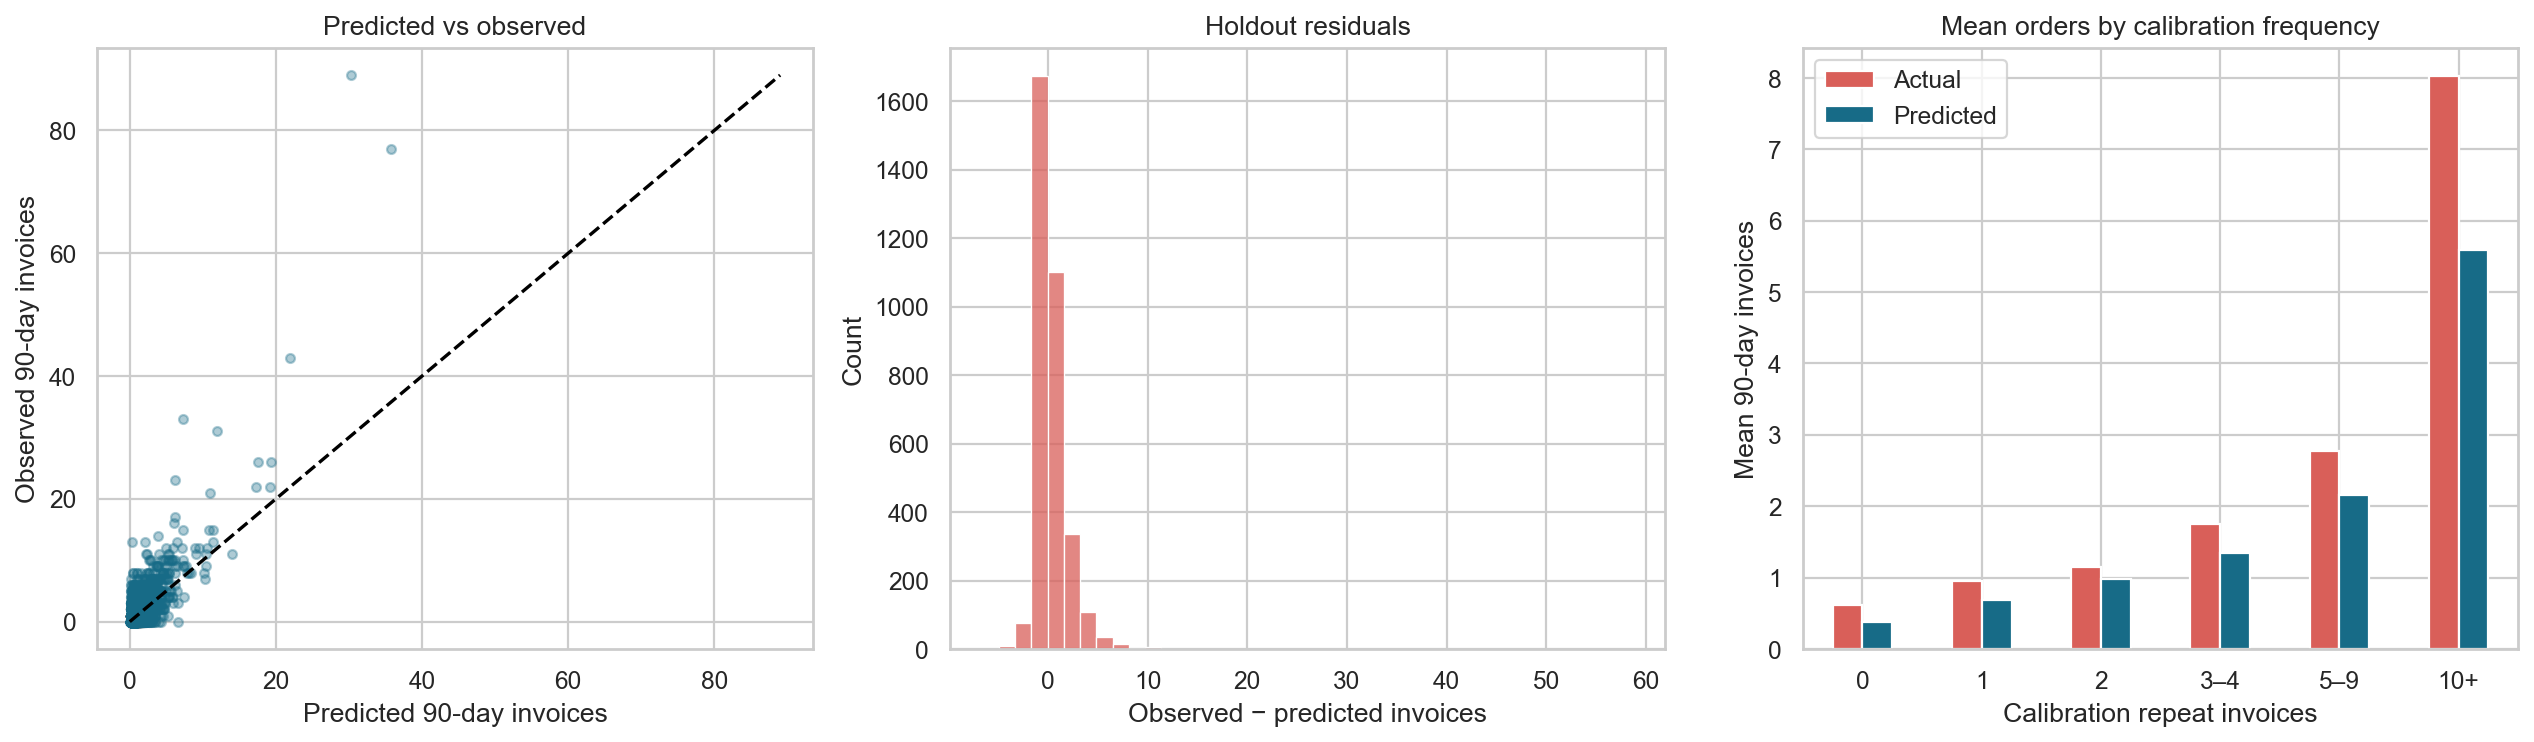

In [10]:
show_table("temporal_snapshot_design.csv"); show_table("model_validation_metrics.csv"); show_figures("06_bgnbd_holdout_validation.png")

## 11. 12-Month Discounted CLV


Each month's expected orders are the difference between consecutive cumulative BG/NBD predictions. Revenue is multiplied by the assumed 30% margin and discounted monthly. Totals are **£10,369,750 revenue**, **£3,110,925 margin**, and **£2,955,975 discounted CLV**.

In [11]:
show_table("monthly_clv_runrate.csv")

,Month,HorizonDays,ExpectedOrders,ExpectedRevenueGBP,ExpectedGrossMarginGBP,DiscountFactor,DiscountedGrossMarginGBP
0,1,30.4167,"1,778.1674","873,627.5126","262,088.2538",0.9921,"260,014.8588"
1,2,60.8333,"1,772.8670","871,146.6438","261,343.9931",0.9842,"257,225.3351"
2,3,91.2500,"1,768.4113","869,048.4121","260,714.5236",0.9765,"254,575.7628"
3,4,121.6667,"1,764.5319","867,212.7656","260,163.8297",0.9687,"252,028.3262"
4,5,152.0833,"1,761.0793","865,572.7947","259,671.8384",0.9611,"249,561.6800"
5,6,182.5000,"1,757.9593","864,086.2185","259,225.8655",0.9535,"247,162.1650"
6,7,212.9167,"1,755.1079","862,724.1176","258,817.2353",0.9459,"244,820.3197"
7,8,243.3333,"1,752.4790","861,465.5987","258,439.6796",0.9384,"242,529.2203"
8,9,273.7500,"1,750.0383","860,294.9474","258,088.4842",0.9310,"240,283.5906"
9,10,304.1667,"1,747.7590","859,199.9752","257,759.9926",0.9236,"238,079.2832"


,Month,HorizonDays,ExpectedOrders,ExpectedRevenueGBP,ExpectedGrossMarginGBP,DiscountFactor,DiscountedGrossMarginGBP
0,1,30.4167,"1,778.1674","873,627.5126","262,088.2538",0.9921,"260,014.8588"
1,2,60.8333,"1,772.8670","871,146.6438","261,343.9931",0.9842,"257,225.3351"
2,3,91.2500,"1,768.4113","869,048.4121","260,714.5236",0.9765,"254,575.7628"
3,4,121.6667,"1,764.5319","867,212.7656","260,163.8297",0.9687,"252,028.3262"
4,5,152.0833,"1,761.0793","865,572.7947","259,671.8384",0.9611,"249,561.6800"
5,6,182.5000,"1,757.9593","864,086.2185","259,225.8655",0.9535,"247,162.1650"
6,7,212.9167,"1,755.1079","862,724.1176","258,817.2353",0.9459,"244,820.3197"
7,8,243.3333,"1,752.4790","861,465.5987","258,439.6796",0.9384,"242,529.2203"
8,9,273.7500,"1,750.0383","860,294.9474","258,088.4842",0.9310,"240,283.5906"
9,10,304.1667,"1,747.7590","859,199.9752","257,759.9926",0.9236,"238,079.2832"


## 12. Customer Value and Latent-Risk Matrix


Whales are the top 10%, High Value the next 10%, Mid Value the next 40%, and Long Tail the bottom 40%. Probability Alive is latent activity—not observed churn. Thresholds 0.30 and 0.50 identify no high-value risk; 0.70 flags only 42 customers overall and **3 high-LTV customers**, so the operational scope remains conservative.

,ProbabilityAliveThreshold,AllHighRiskCustomers,HighValueHighRiskCustomers,CLVAtRiskGBP
0,0.3000,11,0,0.0000
1,0.5000,15,0,0.0000
2,0.7000,42,3,"20,595.0270"


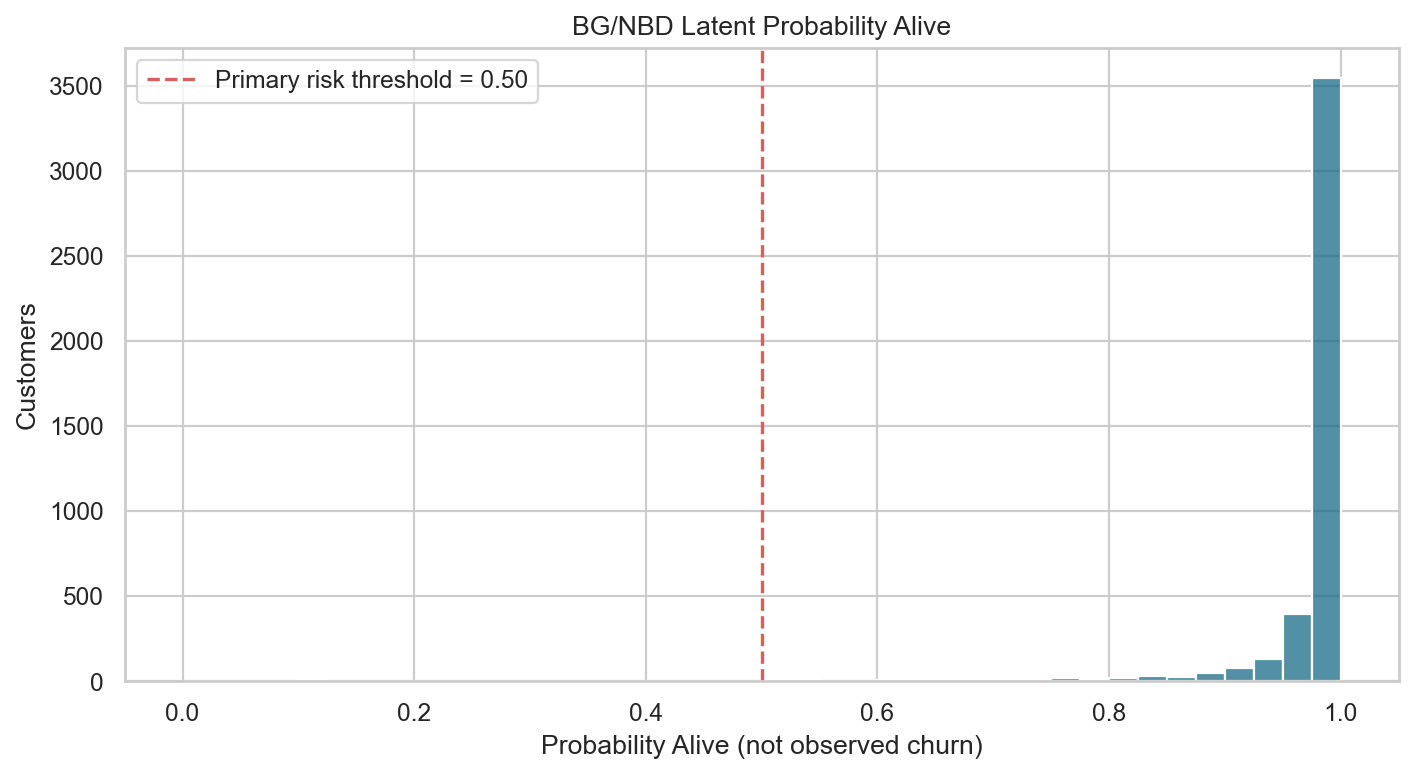

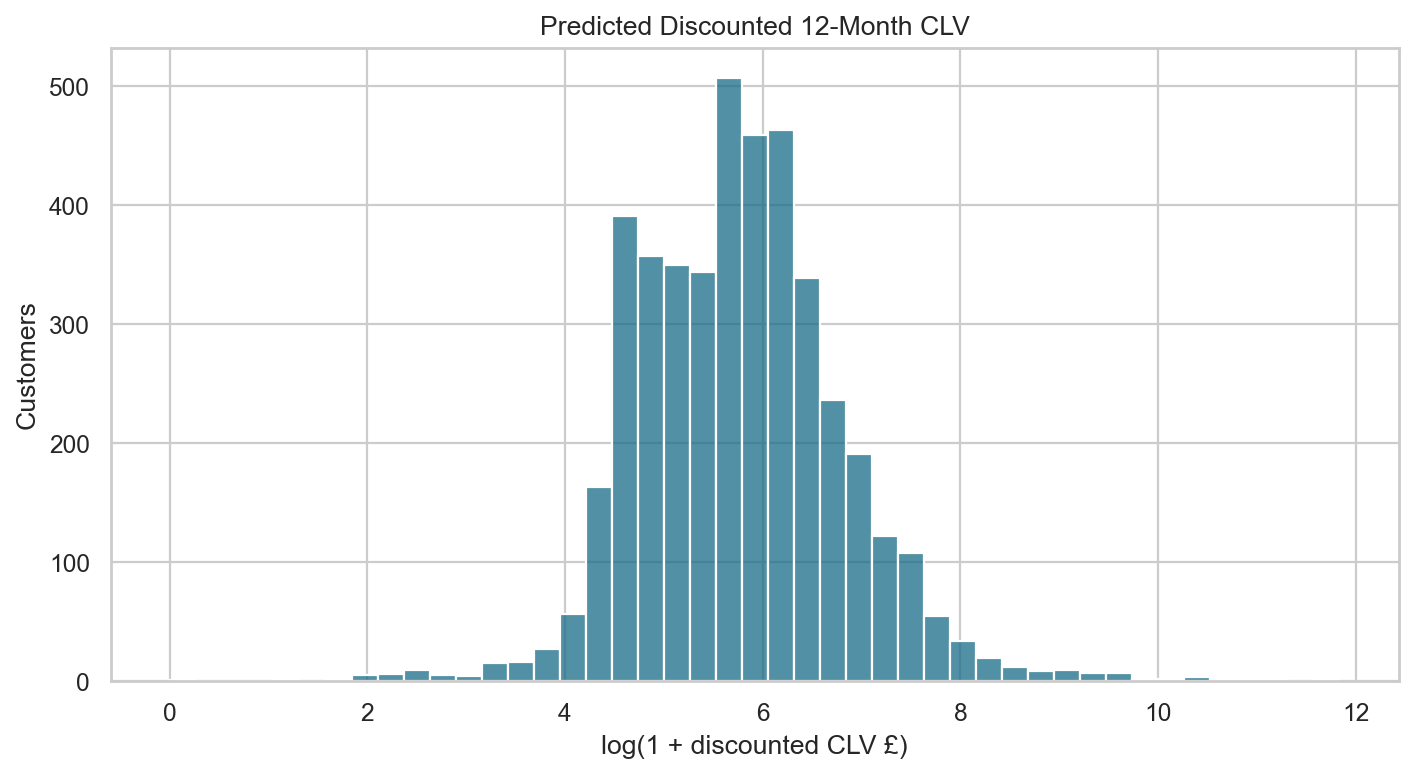

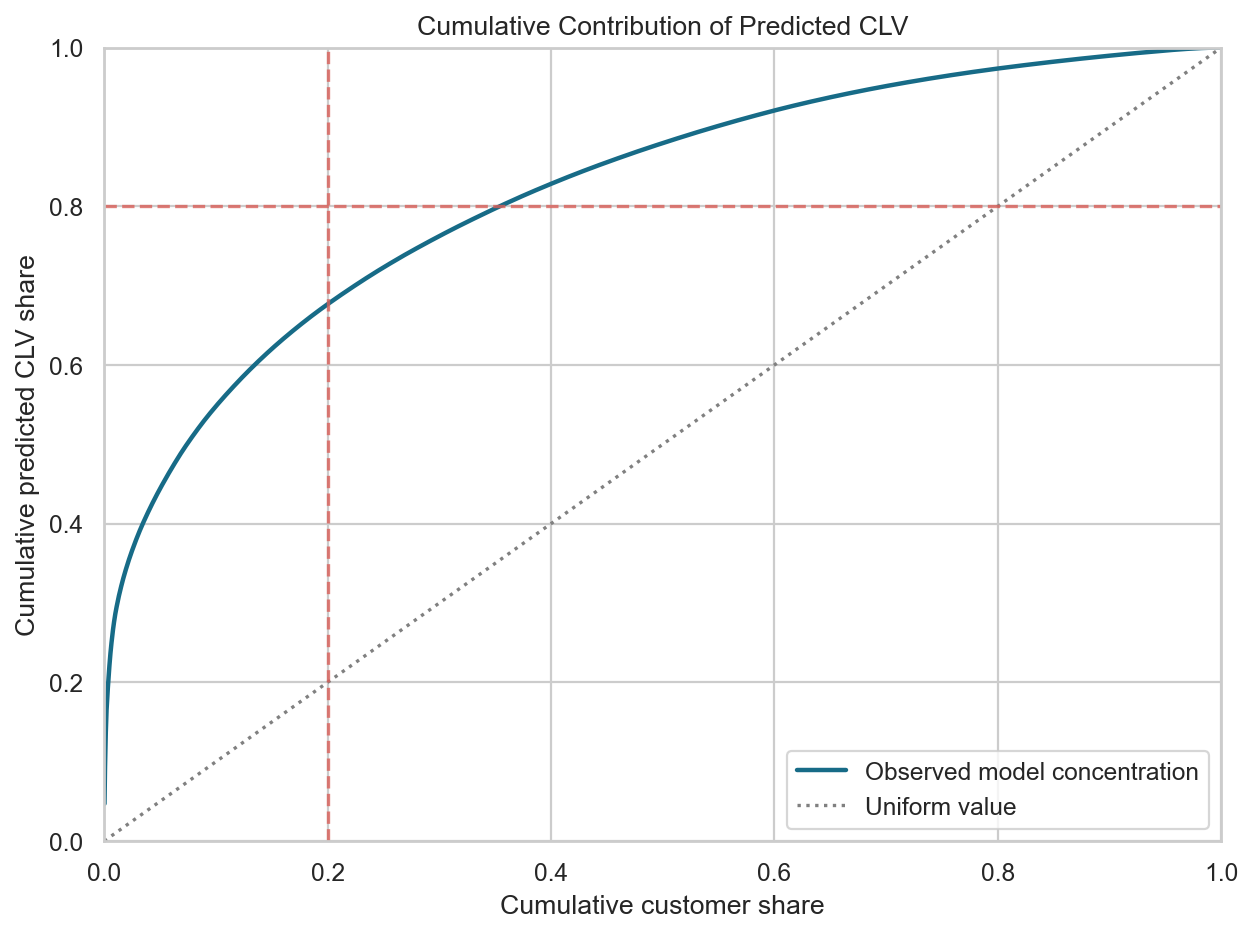

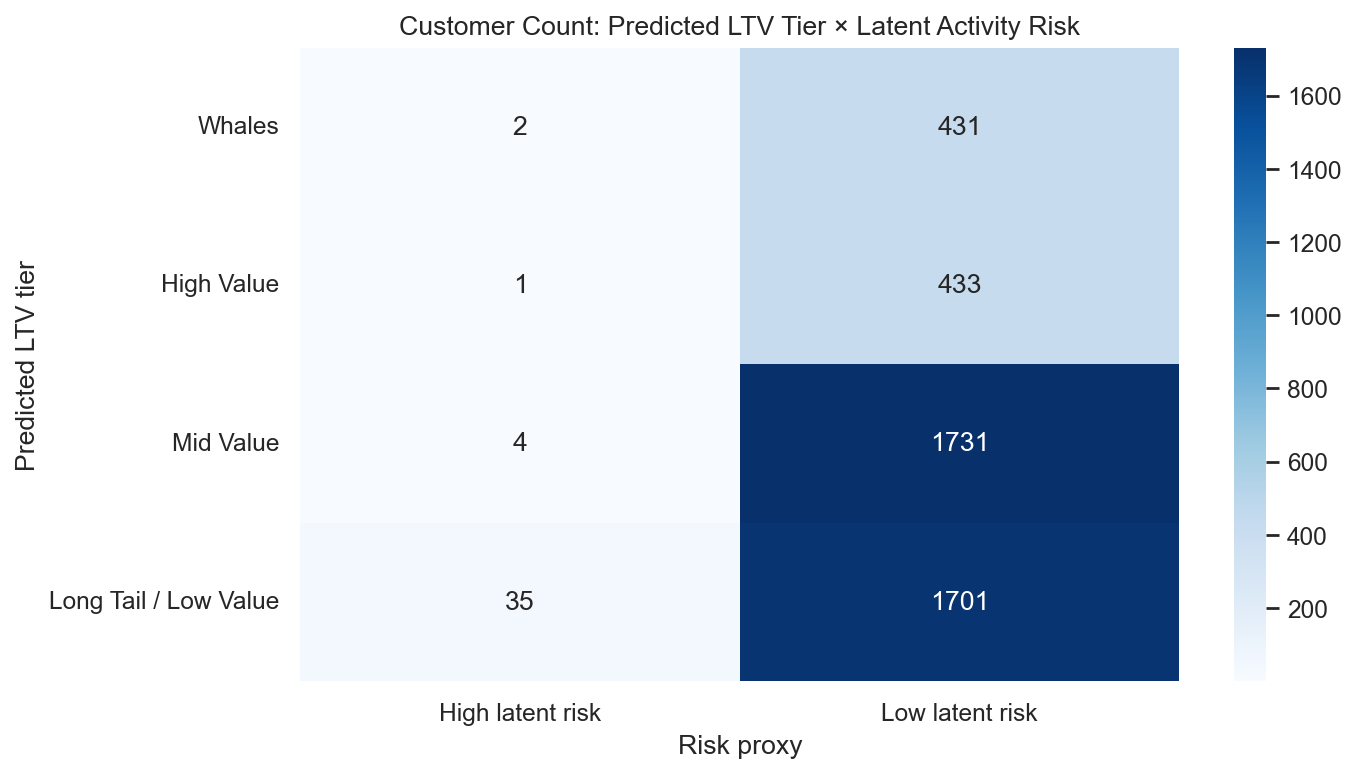

In [12]:
show_table("risk_threshold_sensitivity.csv"); show_figures("07_probability_alive_distribution.png", "08_predicted_clv_distribution.png", "09_clv_pareto_curve.png", "10_ltv_risk_matrix.png")

## 13. LightGBM 90-Day Spend Benchmark


Every feature is recomputed at or before its cutoff; the target is strictly `(cutoff, cutoff + 90 days]`. Training target windows end before validation features, and validation targets end before final-test features. Tweedie regression is an implementation extension suited to a non-negative, zero-heavy target.

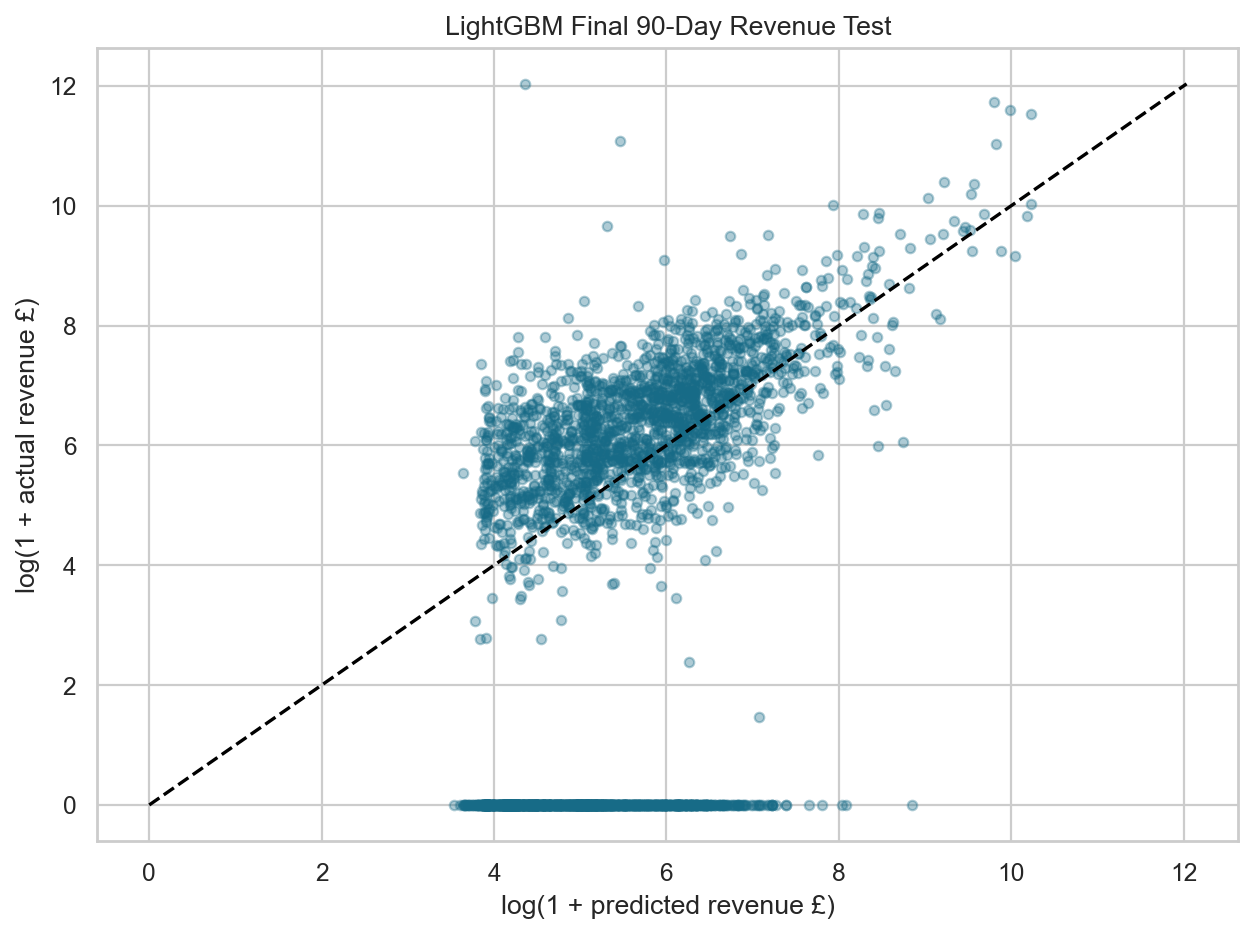

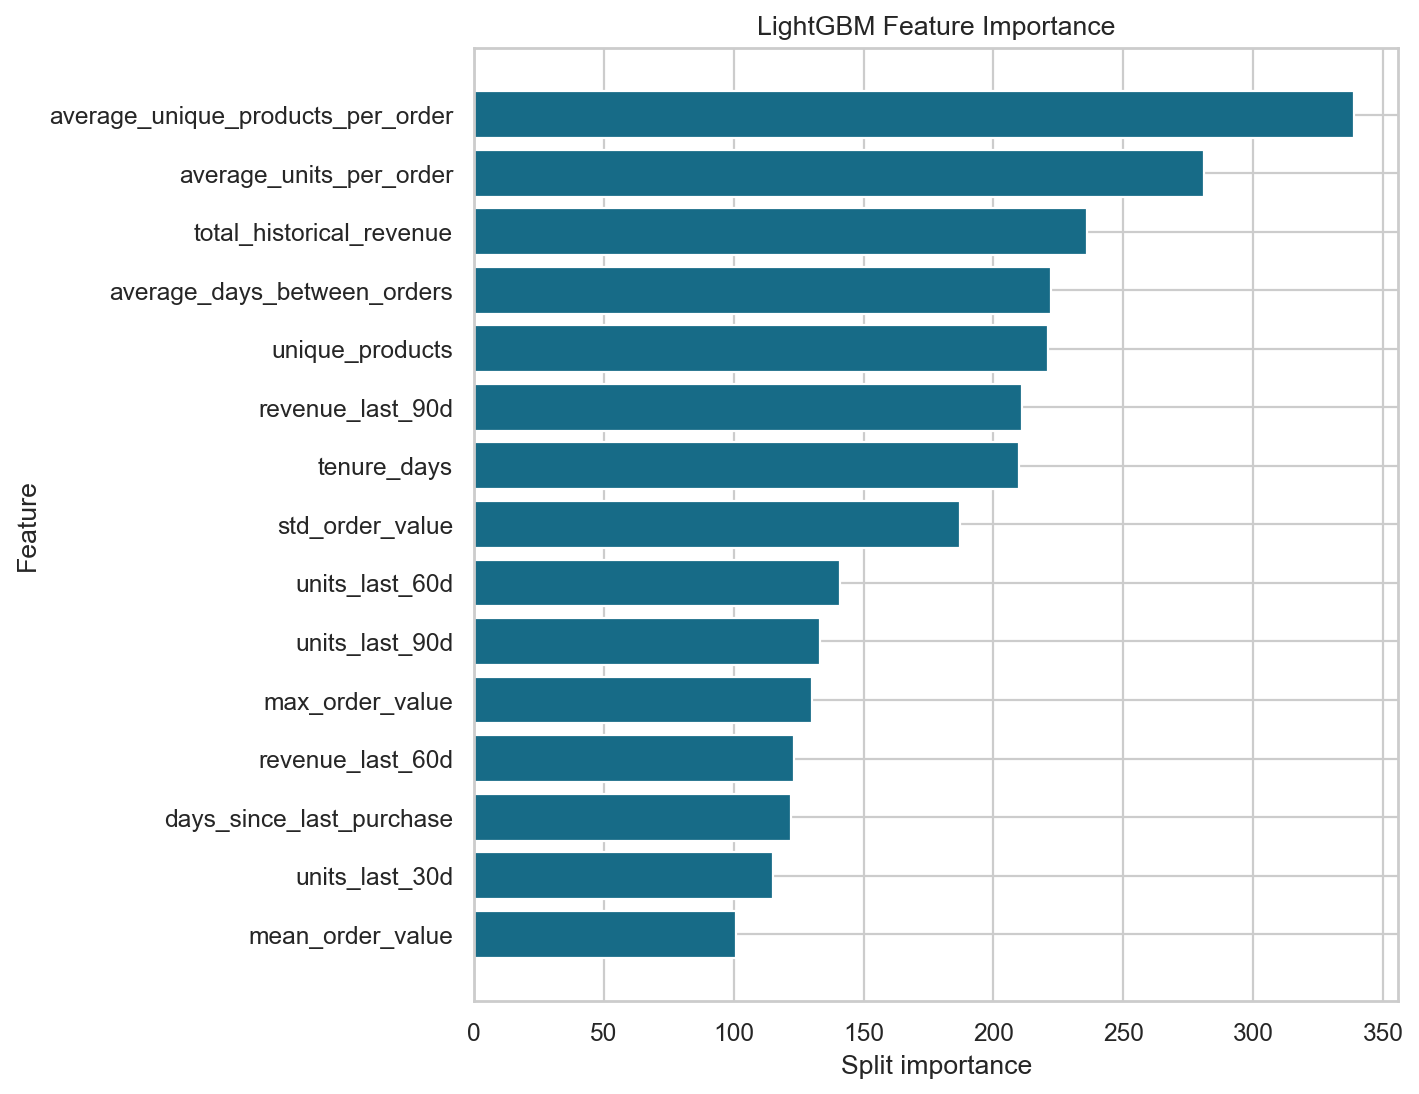

,Feature,Importance
0,average_unique_products_per_order,339
1,average_units_per_order,281
2,total_historical_revenue,236
3,average_days_between_orders,222
4,unique_products,221
5,revenue_last_90d,211
6,tenure_days,210
7,std_order_value,187
8,units_last_60d,141
9,units_last_90d,133


,Feature,Importance
0,average_unique_products_per_order,339
1,average_units_per_order,281
2,total_historical_revenue,236
3,average_days_between_orders,222
4,unique_products,221
...,...,...
56,country_European Community,0
57,country_Finland,0
58,country_Greece,0
59,country_Iceland,0


In [13]:
show_figures("11_lightgbm_actual_vs_predicted.png", "12_lightgbm_feature_importance.png"); show_table("lightgbm_feature_importance.csv", 15)

## 14. Model Performance


LightGBM final-test MAE is **£652**, better than baseline **£721**. Its RMSE is **£4,363**, worse than baseline **£4,102**, so it does not dominate. Top-decile lift is **5.16×** for LightGBM and **5.23×** for BG/NBD + Gamma-Gamma; the 3.5× lecture benchmark was not forced.

,Model,MAE,RMSE,TopDecileSpendCapture,TopDecileLift,CustomersEvaluated
0,BG/NBD holdout orders,1.0626,2.1042,0.3946,3.9463,3370
1,BG/NBD + Gamma-Gamma holdout revenue,636.3067,"4,125.3989",0.5227,5.2273,3370
2,LightGBM validation revenue,473.0791,"1,800.9029",0.6001,6.0015,2815
3,Historic-rate baseline test revenue,720.5100,"4,101.5534",0.4918,4.9182,3370
4,LightGBM final test revenue,652.0274,"4,362.9691",0.5163,5.1626,3370


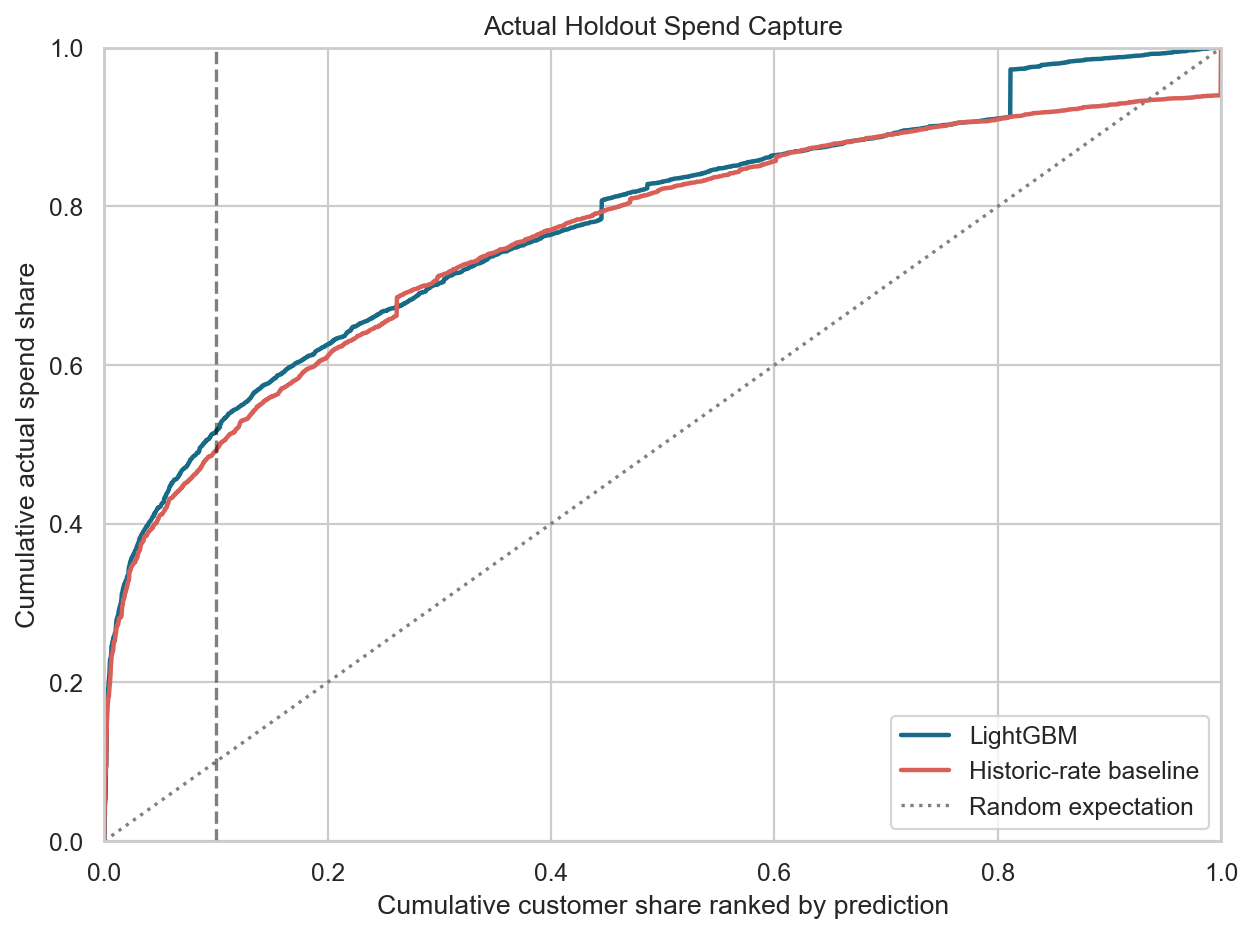

In [14]:
show_table("model_validation_metrics.csv"); show_figures("13_top_decile_capture_curves.png")

## 15. Financial Run-Rate Impact


The model-estimated annual revenue run-rate is **£10,369,750**. Applying the 30% course margin assumption gives **£3,110,925**; discounting gives **£2,955,975**. The high-LTV/high-risk cell contains **£20,595** of discounted CLV.

In [15]:
show_table("financial_run_rate_summary.csv"); show_table("clv_concentration.csv")

,Metric,Value,Classification
0,Total predicted 12-month revenue run-rate,"10,369,750.1365",MODEL ESTIMATE
1,Total predicted 12-month gross-margin run-rate,"3,110,925.0409",MODEL ESTIMATE + 30% COURSE ASSUMPTION
2,Total discounted 12-month CLV,"2,955,975.3579",MODEL ESTIMATE + COURSE ASSUMPTIONS
3,High-LTV/high-risk customer count,3.0000,MODEL-DERIVED SEGMENT
4,Discounted CLV in high-LTV/high-risk segment,"20,595.0270",MODEL ESTIMATE


,Metric,Value
0,Observed historical revenue share from top 10%,0.6145208192064804
1,Predicted CLV share from top 10%,0.5480641954621055
2,Predicted CLV share from top 20%,0.6766495645357656
3,Customers required for 80% of predicted CLV,1537
4,Customer share required for 80% of predicted CLV,0.3543107422775473
5,Strict 80/20 pattern (top 20% >= 80% of CLV),False


,Metric,Value
0,Observed historical revenue share from top 10%,0.6145208192064804
1,Predicted CLV share from top 10%,0.5480641954621055
2,Predicted CLV share from top 20%,0.6766495645357656
3,Customers required for 80% of predicted CLV,1537
4,Customer share required for 80% of predicted CLV,0.3543107422775473
5,Strict 80/20 pattern (top 20% >= 80% of CLV),False


## 16. LTV/CAC Capital Allocation


Observed CAC is unavailable and never fabricated. Customer ceilings are `CLV/3` for the target 3× ratio, `CLV/1.5` as the kill-level threshold, and discounted expected margin in months 1–6 for payback. These are allowable maxima, not historical CAC.

In [16]:
show_table("ltv_cac_summary_by_tier.csv"); show_table("ltv_cac_thresholds.csv", 10)

,ltv_tier,Customers,TotalDiscountedCLVGBP,MeanMaxCAC3xGBP,MedianMaxCAC3xGBP,MeanKillLevelCAC1_5xGBP,MeanSixMonthMaxCACGBP
0,Whales,433,"1,618,934.6940","1,246.2931",591.0859,"2,492.5861","1,922.1367"
1,High Value,434,"380,541.2684",292.2744,287.4941,584.5488,450.9609
2,Mid Value,1735,"721,826.5030",138.6794,131.7868,277.3589,214.3072
3,Long Tail / Low Value,1736,"234,672.8925",45.0601,41.9072,90.1202,69.5523


,CustomerID,ltv_tier,discounted_clv_12m,max_cac_3x,max_cac_1_5x,max_cac_6m_payback
0,12346,Long Tail / Low Value,94.7501,31.5834,63.1667,48.7174
1,12347,High Value,"1,023.8601",341.2867,682.5734,525.9104
2,12348,Mid Value,298.0707,99.3569,198.7138,153.1292
3,12349,Mid Value,507.4104,169.1368,338.2736,262.2992
4,12350,Long Tail / Low Value,98.7254,32.9085,65.8170,50.7675
5,12352,High Value,739.6270,246.5423,493.0847,380.0828
6,12353,Long Tail / Low Value,139.4500,46.4833,92.9667,71.7860
7,12354,Long Tail / Low Value,125.6654,41.8885,83.7769,64.6685
8,12355,Long Tail / Low Value,134.1435,44.7145,89.4290,69.0457
9,12356,Long Tail / Low Value,219.9031,73.3010,146.6020,113.0046


,CustomerID,ltv_tier,discounted_clv_12m,max_cac_3x,max_cac_1_5x,max_cac_6m_payback
0,12346,Long Tail / Low Value,94.7501,31.5834,63.1667,48.7174
1,12347,High Value,"1,023.8601",341.2867,682.5734,525.9104
2,12348,Mid Value,298.0707,99.3569,198.7138,153.1292
3,12349,Mid Value,507.4104,169.1368,338.2736,262.2992
4,12350,Long Tail / Low Value,98.7254,32.9085,65.8170,50.7675
...,...,...,...,...,...,...
4333,18280,Long Tail / Low Value,108.5022,36.1674,72.3348,55.8108
4334,18281,Long Tail / Low Value,153.6318,51.2106,102.4212,79.1113
4335,18282,Long Tail / Low Value,96.7981,32.2660,64.5321,49.8623
4336,18283,Mid Value,547.1280,182.3760,364.7520,281.0632


## 17. Retention Scenario Analysis


**SCENARIO ANALYSIS — NOT CAUSAL ESTIMATES.** Targeting only 3 high-LTV/high-risk customers, +5%, +10%, and +15% hypothetical order uplift yields **£1,030**, **£2,060**, and **£3,089** discounted incremental margin.

,ScenarioLabel,OrderUplift,TargetCustomers,IncrementalExpectedOrders,IncrementalRevenueGBP,IncrementalGrossMarginGBP,DiscountedIncrementalMarginGBP,BreakEvenSpendPerTargetCustomerGBP
0,SCENARIO ANALYSIS — NOT A CAUSAL ESTIMATE,0.0500,3,1.1685,"3,612.3618","1,083.7085","1,029.7513",343.2504
1,SCENARIO ANALYSIS — NOT A CAUSAL ESTIMATE,0.1000,3,2.3370,"7,224.7236","2,167.4171","2,059.5027",686.5009
2,SCENARIO ANALYSIS — NOT A CAUSAL ESTIMATE,0.1500,3,3.5055,"10,837.0855","3,251.1256","3,089.2540","1,029.7513"


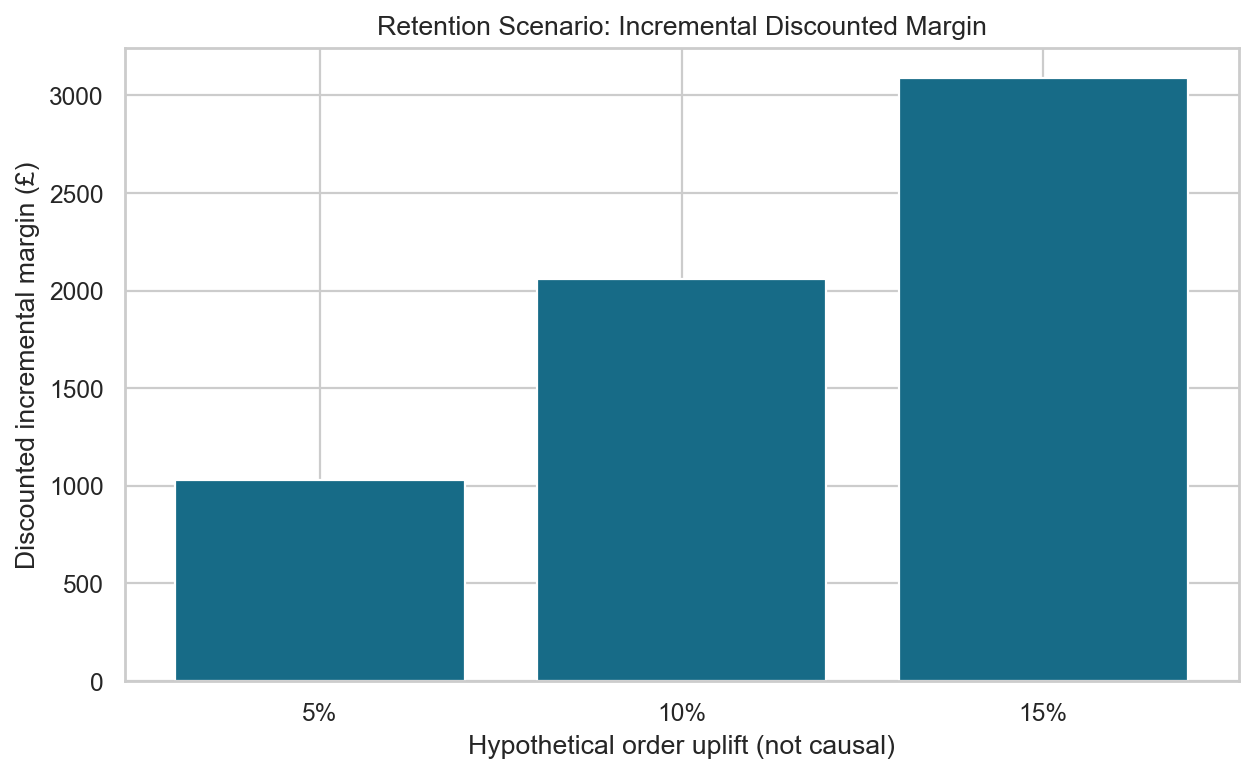

In [17]:
show_table("retention_sensitivity.csv"); show_figures("14_retention_sensitivity.png")

## 18. Type 1 vs Type 2 Recommendations


**Type 2—test first:** targeted email, capped digital voucher, app notification, temporary VIP perk, and A/B-tested messaging. **Type 1—require stronger evidence:** permanent VIP infrastructure, long-term SLA changes, physical process redesign, or durable capital reallocation. Observational CLV alone does not justify irreversible spending.

## 19. Limitations


The history spans roughly one year. Gross margin, cost, CAC, marketing exposure, and intervention treatment are absent. Probability Alive is latent. Gamma-Gamma shows mild monotonic dependence and needs an observed fallback for one-time buyers. The course BG/NBD penalty is numerically invalid for some long-horizon scores. LightGBM improves MAE but not RMSE. Retention uplift is hypothetical and requires an experiment for causal validation.

## 20. Final Executive Recommendations


1. Usable customers: **4,338**.
2. One-time vs repeat: **1,493 (34.4%)** vs **2,845 (65.6%)**.
3. Highest CLV CustomerIDs: **16446, 14646, 18102, 17450, 14096**.
4. High-value / low Probability Alive: **3 customers** at 0.70; IDs/actions are in `customer_action_matrix.csv`.
5. BG/NBD order holdout: **MAE 1.063; RMSE 2.104**.
6. Gamma-Gamma assumption: Pearson **0.011**, Spearman **0.209**; independence is not proven.
7. Predicted revenue: **£10,369,750**.
8. Predicted gross margin: **£3,110,925** under 30% assumed margin.
9. Discounted CLV: **£2,955,975**.
10. Top-10% / top-20% CLV share: **54.8% / 67.7%**.
11. 80/20: **No**; **35.4%** of customers are needed for 80% of CLV.
12. Top-decile lift: **5.23× BG/GG; 5.16× LightGBM**.
13. LightGBM: better MAE, worse RMSE than baseline; no clean win.
14. CAC: use CLV/3, CLV/1.5, and six-month discounted margin ceilings in the customer table.
15. Fund retention for the **3 high-LTV/high-risk customers** through capped Type 2 tests.
16. Use no paid rescue for low-LTV/high-risk customers; keep communication organic.
17. Scenario margin at +5%/+10%/+15%: **£1,030 / £2,060 / £3,089**.
18. Ten-percent scenario break-even spend: **£687 per target**.
19. Type 1: permanent infrastructure, SLA, physical-process, and durable capital changes.
20. Type 2: targeted digital offers, temporary perks, and randomized tests.

**Management action:** do not spread discounts evenly. Protect healthy whales with service benefits, test retention only in the small high-value/high-risk cell, avoid paid rescue of the low-value tail, and demand causal evidence before scaling permanent spend. The model prioritizes decisions; it is not a crystal ball wearing a tie.